# spaCy Narrative EDA

Learning-oriented tour of spaCy on the deduped SGO crash narratives.

Capability groups exercised: linguistic features (tokens, POS, lemmas, sentences, noun chunks), NER, rule-based matching (Matcher + PhraseMatcher), displaCy rendering, and token / doc similarity.

Each section writes at least one persisted artifact under `artifacts_spacy/<section>/` so the results survive a kernel restart.

## Environment

Uses the sidecar Python 3.12 env -- spaCy has no Python 3.14 wheels as of 2026-05.

```bash
source ~/claude_code_repos/my-uv-envs/avird-2026-eda-spacy/.venv/Scripts/activate
uv pip install -r ~/claude_code_repos/my-uv-envs/avird-2026-eda-spacy/requirements.txt
```

The `en_core_web_lg` model wheel is pinned in `requirements.txt`, so no separate `python -m spacy download` step is needed.

## 0. Setup

In [2]:
import sys
sys.path.append('..')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import eda_utils_sgo
import eda_utils_dedupe
import eda_utils_treatment
import eda_utils_spacy

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 300)

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
ARTIFACTS = Path('artifacts_spacy')
for sub in ['linguistic', 'ner', 'matchers', 'displacy/ent', 'displacy/dep',
            'similarity', '_docbin']:
    (ARTIFACTS / sub).mkdir(parents=True, exist_ok=True)
print('artifact root:', ARTIFACTS.resolve())

artifact root: C:\Users\james\claude_code_repos\avird-2026-eda-v001-spacy\eda\ADS_to_2026_03_16\artifacts_spacy


## 1. Load and Treat Data

Same dedupe + treatment preamble as `03_eda_basic_topics_2026.ipynb`. We use the single-report `Narrative` column (not the `Narrative - Same Incident ID` concat) by default -- the `--- next report ---` separator pollutes sentence segmentation.

In [5]:
repo_root = Path.cwd().parents[1]
data_dir = repo_root / 'data' / 'nhtsa'
paths = [
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv',
    data_dir / 'SGO-2021-01_Incident_Reports_ADS_2025_06_16_to_2026_03_16.csv',
]
ads_df = eda_utils_sgo.load_and_concat_csvs(paths)

Only in SGO-2021-01_Incident_Reports_ADS_to_2025_06_16.csv:
  ADAS/ADS Hardware Version
  ADAS/ADS Hardware Version - Unk
  ADAS/ADS Hardware Version CBI
  ADAS/ADS Software Version
  ADAS/ADS Software Version - Unk
  ADAS/ADS Software Version CBI
  ADAS/ADS System Version
  ADAS/ADS System Version - Unk
  ADAS/ADS System Version CBI
  ADS Equipped?
  CP Any Air Bags Deployed?
  CP Was Vehicle Towed?
  Federal Reg. Exemption - No
  Federal Reg. Exemption - Unk
  Federal Regulatory Exemption?
  Inv. Officer Email - Unknown
  Inv. Officer Name - Unknown
  Inv. Officer Phone - Unknown
  Investigating Officer Email
  Investigating Officer Name
  Investigating Officer Phone
  Law Enforcement Investigating?
  Lighting
  Mileage
  Mileage - Unknown
  Notice Received Date
  Other Federal Reg. Exemption
  Other Reporting Entities?
  Other Reporting Entities? - NA
  Other Reporting Entities? - Unk
  Posted Speed Limit (MPH)
  Posted Speed Limit - Unknown
  Property Damage?
  Rep Ent Or Mfr Inves

In [6]:
entity_column = 'master_entity'
treated_df = eda_utils_dedupe.dedupe_same_incident(ads_df.copy(), verbose=True)
treated_df = eda_utils_treatment.apply_all_treatments(treated_df)
narratives = treated_df['Narrative']
print('rows:', len(treated_df), 'non-null narratives:', narratives.notna().sum())

dedupe_same_incident: 3120 -> 2344 rows (776 duplicates collapsed)
rows: 2344 non-null narratives: 2342


## 2. Parse the corpus once via `nlp.pipe` + DocBin

First run parses the ~2.3k narratives end-to-end (several minutes on CPU). DocBin caches the parsed `Doc` objects to disk; re-runs load in seconds. Cache key is a content hash of the (preprocessed) narrative list, so any change upstream invalidates it automatically.

In [7]:
nlp = eda_utils_spacy.load_nlp()
print('model:', nlp.meta['name'], 'version:', nlp.meta['version'])
print('pipeline:', nlp.pipe_names)

model: core_web_lg version: 3.8.0
pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


In [8]:
t0 = time.time()
docs, doc_index = eda_utils_spacy.parse_corpus(
    narratives, nlp=nlp, cache_dir=ARTIFACTS / '_docbin', batch_size=64,
)
print(f'parsed {len(docs)} docs in {time.time() - t0:.1f}s')
print('sample doc:', docs[0].text[:200], '...')

parsed 2342 docs in 41.6s
sample doc: Other than an update to the highest severity injury alleged field to reflect a minor injury (which is also reflected in the narrative below), the content of this report is unchanged from the initial r ...


In [10]:
narratives[0]

'Other than an update to the highest severity injury alleged field to reflect a minor injury (which is also reflected in the narrative below), the content of this report is unchanged from the initial report submitted on August 12, 2025 [REDACTED, MAY CONTAIN CONFIDENTIAL BUSINESS INFORMATION].\r\nOn August [XXX], 2025 at 4:54 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX]. \r\nThe Waymo AV was stopped in the rightmost lane facing northeast on [XXX] in a queue of traffic at the intersection with [XXX] at a location where the rightmost lane and leftmost lane are separated by a raised transit boarding island. As the queue of traffic advanced, the Waymo AV began moving forward. A scooterist traveling northeastbound in the rightmost lane proceeded to pass to the right of the Waymo AV followed closely by a cyclist, and the Waymo AV shifted left towards the raised boarding island and slowed to

In [9]:
docs[0]

Other than an update to the highest severity injury alleged field to reflect a minor injury (which is also reflected in the narrative below), the content of this report is unchanged from the initial report submitted on August 12, 2025 <REDACTED>. On August [XXX], 2025 at 4:54 PM PT a Waymo Autonomous Vehicle ("Waymo AV") operating in San Francisco, California was in a collision involving a passenger car on [XXX] at [XXX]. The Waymo AV was stopped in the rightmost lane facing northeast on [XXX] in a queue of traffic at the intersection with [XXX] at a location where the rightmost lane and leftmost lane are separated by a raised transit boarding island. As the queue of traffic advanced, the Waymo AV began moving forward. A scooterist traveling northeastbound in the rightmost lane proceeded to pass to the right of the Waymo AV followed closely by a cyclist, and the Waymo AV shifted left towards the raised boarding island and slowed to a stop to yield to the scooterist and cyclist. A passe

In [11]:
doc_index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2334, 2335, 2336, 2337, 2338, 2339, 2340, 2341, 2342, 2343],
      dtype='int64', length=2342)

In [12]:
doc = docs[0]
print(type(doc))          # <class 'spacy.tokens.Doc'>
print(len(doc))           # number of tokens
print(doc[0])             # first Token — also prints as its text
print(type(doc[0]))       # <class 'spacy.tokens.Token'>

#Iterate to see the tokens:

for tok in doc[:15]:
    print(f"{tok.text:<20} pos={tok.pos_:<6} tag={tok.tag_:<6} "
        f"lemma={tok.lemma_:<15} dep={tok.dep_:<12} stop={tok.is_stop}")


<class 'spacy.tokens.doc.Doc'>
310
Other
<class 'spacy.tokens.token.Token'>
Other                pos=ADJ    tag=JJ     lemma=other           dep=advmod       stop=True
than                 pos=ADP    tag=IN     lemma=than            dep=prep         stop=True
an                   pos=DET    tag=DT     lemma=an              dep=det          stop=True
update               pos=NOUN   tag=NN     lemma=update          dep=pobj         stop=False
to                   pos=ADP    tag=IN     lemma=to              dep=prep         stop=True
the                  pos=DET    tag=DT     lemma=the             dep=det          stop=True
highest              pos=ADJ    tag=JJS    lemma=high            dep=amod         stop=False
severity             pos=NOUN   tag=NN     lemma=severity        dep=compound     stop=False
injury               pos=NOUN   tag=NN     lemma=injury          dep=nmod         stop=False
alleged              pos=VERB   tag=VBN    lemma=allege          dep=amod         stop=False

## 3. Linguistic features

Tokens, POS, lemmas, sentence segmentation. Outputs:
* `linguistic/top_verbs.csv`, `top_nouns.csv`, `top_adjs.csv`
* `linguistic/sentence_stats.csv`
* histogram of sentences per narrative

In [13]:
extra_stop = eda_utils_spacy.DEFAULT_EXTRA_STOPWORDS

for pos in ['VERB', 'NOUN', 'ADJ']:
    df = eda_utils_spacy.top_lemmas_by_pos(
        docs, doc_index, pos=pos, top_k=30, extra_stop=extra_stop
    )
    out = ARTIFACTS / 'linguistic' / f'top_{pos.lower()}s.csv'
    df.to_csv(out, index=False)
    print(out.name)
    display(df.head(15))

top_verbs.csv


,lemma,pos,count
0,involve,VERB,2733
1,travel,VERB,2216
2,operate,VERB,2133
3,sustain,VERB,1938
4,engage,VERB,1852
5,stop,VERB,1823
6,correct,VERB,1781
7,supplement,VERB,1760
8,leave,VERB,891
9,proceed,VERB,803


top_nouns.csv


,lemma,pos,count
0,passenger,NOUN,3756
1,lane,NOUN,2661
2,car,NOUN,2498
3,time,NOUN,2237
4,mode,NOUN,2173
5,contact,NOUN,2165
6,damage,NOUN,2091
7,collision,NOUN,2044
8,information,NOUN,1903
9,impact,NOUN,1856


top_adjs.csv


,lemma,pos,count
0,autonomous,ADJ,2093
1,additional,ADJ,1787
2,available,ADJ,1775
3,right,ADJ,1342
4,rear,ADJ,1089
5,left,ADJ,921
6,stationary,ADJ,712
7,heavy,ADJ,539
8,red,ADJ,528
9,second,ADJ,345


,doc_index,n_sentences,mean_sent_len_tokens,max_sent_len_tokens
count,2342.000000,2342.000000,2342.000000,2342.000000
mean,1171.483348,7.640051,24.499891,45.498719
std,676.994608,2.208829,4.342765,10.037637
min,0.000000,1.000000,3.000000,3.000000
25%,585.250000,7.000000,22.666667,42.000000
50%,1171.500000,7.000000,24.571429,44.000000
75%,1757.750000,9.000000,26.833333,48.750000
max,2343.000000,34.000000,41.285714,150.000000


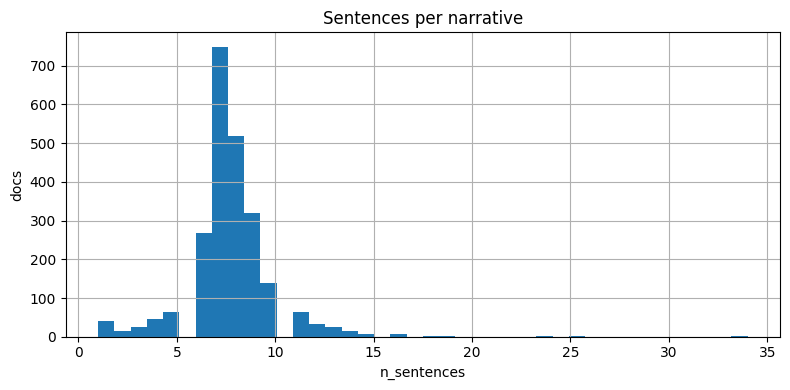

In [14]:
sent_df = eda_utils_spacy.sentence_stats(docs, doc_index)
sent_df.to_csv(ARTIFACTS / 'linguistic' / 'sentence_stats.csv', index=False)
display(sent_df.describe())

fig, ax = plt.subplots(figsize=(8, 4))
sent_df['n_sentences'].hist(bins=40, ax=ax)
ax.set_title('Sentences per narrative')
ax.set_xlabel('n_sentences')
ax.set_ylabel('docs')
plt.tight_layout()
fig.savefig(ARTIFACTS / 'linguistic' / 'sentence_count_hist.png', dpi=120)
plt.show()

## 4. Named Entity Recognition

spaCy's stock NER on the SGO narratives. Cross-check against the `master_entity` curated reporter field to see whether the model picks up Waymo / Cruise / Zoox / etc. as `ORG`.

In [15]:
ent_df = eda_utils_spacy.entity_table(docs, doc_index)
ent_df.to_csv(ARTIFACTS / 'ner' / 'entity_table.csv', index=False)
print('total entity spans:', len(ent_df))
print('label counts:')
print(ent_df['label'].value_counts().head(20))

total entity spans: 39356
label counts:
label
ORG            9709
DATE           6541
PRODUCT        5790
WORK_OF_ART    5366
GPE            4645
CARDINAL       4072
TIME           1936
ORDINAL         599
PERSON          235
FAC             201
QUANTITY        100
LOC              79
MONEY            34
NORP             19
LAW              16
EVENT            12
PERCENT           2
Name: count, dtype: int64


In [ ]:
# # import pprint
# # pprint.pprint(docs[0])

# import textwrap


# # Use textwrap.fill to wrap text at 80 characters
# wrapped_text = textwrap.fill(str(docs[0]), width=80)
# wrapped_text

'Other than an update to the highest severity injury alleged field to reflect a\nminor injury (which is also reflected in the narrative below), the content of\nthis report is unchanged from the initial report submitted on August 12, 2025\n<REDACTED>. On August [XXX], 2025 at 4:54 PM PT a Waymo Autonomous Vehicle\n("Waymo AV") operating in San Francisco, California was in a collision involving\na passenger car on [XXX] at [XXX]. The Waymo AV was stopped in the rightmost\nlane facing northeast on [XXX] in a queue of traffic at the intersection with\n[XXX] at a location where the rightmost lane and leftmost lane are separated by\na raised transit boarding island. As the queue of traffic advanced, the Waymo AV\nbegan moving forward. A scooterist traveling northeastbound in the rightmost\nlane proceeded to pass to the right of the Waymo AV followed closely by a\ncyclist, and the Waymo AV shifted left towards the raised boarding island and\nslowed to a stop to yield to the scooterist and cyc

In [ ]:
# me: spot checked these. August is not breaking apart the August 12th but another mention of August
ent_df.head()

,doc_index,text,label,start_char,end_char
0,0,"August 12, 2025",DATE,219,234
1,0,August,DATE,250,256
2,0,2025,DATE,264,268
3,0,4:54 PM PT,TIME,272,282
4,0,Waymo Autonomous Vehicle,ORG,285,309


In [23]:
for label in ['ORG', 'GPE', 'DATE', 'PERSON', 'TIME', 'CARDINAL']:
    df = eda_utils_spacy.entity_counts_by_label(ent_df, label=label, top_k=25)
    if df.empty:
        continue
    out = ARTIFACTS / 'ner' / f'entity_counts_{label}.csv'
    df.to_csv(out, index=False)
    print(out.name)
    display(df.head(15))

entity_counts_ORG.csv


,label,text,count
0,ORG,the waymo av,1851
1,ORG,waymo autonomous vehicle,1779
2,ORG,the waymo av's,1603
3,ORG,gm,1176
4,ORG,standing general order,1005
5,ORG,cruise,597
6,ORG,gm cruise holdings llc,147
7,ORG,order,147
8,ORG,general motors llc,145
9,ORG,waymo,129


entity_counts_GPE.csv


,label,text,count
0,GPE,california,1130
1,GPE,san francisco,808
2,GPE,zoox,560
3,GPE,arizona,429
4,GPE,los angeles,261
5,GPE,mt,254
6,GPE,phoenix,230
7,GPE,texas,171
8,GPE,austin,131
9,GPE,tempe,104


entity_counts_DATE.csv


...

,label,text,count
0,PERSON,transdev,111
1,PERSON,waymo,49
2,PERSON,zoox,10
3,PERSON,olli,6
4,PERSON,vehicle2,5
5,PERSON,waymollc-202111[xxx]-0,4
6,PERSON,waymollc-202112[xxx]-0,3
7,PERSON,rrai,2
8,PERSON,avride,2
9,PERSON,ghost,2


entity_counts_TIME.csv


,label,text,count
0,TIME,12:23 am pt,5
1,TIME,30 seconds,5
2,TIME,5:09 pm pt,5
3,TIME,6:25 pm,5
4,TIME,9:00 am pt,5
5,TIME,8:48 pm pt,5
6,TIME,8:51 pm,5
7,TIME,3:58 pm pt,4
8,TIME,3:13 pm,4
9,TIME,11:17 am pt,4


entity_counts_CARDINAL.csv


,label,text,count
0,CARDINAL,4,1512
1,CARDINAL,2,1077
2,CARDINAL,1,826
3,CARDINAL,two,165
4,CARDINAL,three,90
5,CARDINAL,30412,76
6,CARDINAL,one,66
7,CARDINAL,four,28
8,CARDINAL,30270,25
9,CARDINAL,3,20


In [24]:
crosstab = eda_utils_spacy.org_vs_master_entity_crosstab(
    ent_df, treated_df, master_entity_col=entity_column, top_k_orgs=15
)
crosstab.to_csv(ARTIFACTS / 'ner' / 'org_vs_master_entity_crosstab.csv')
with pd.option_context('display.max_colwidth', None):
    display(crosstab)

text,av,cruise,general motors llc,gm,gm cruise holdings llc,motional,northeastbound,order,standing general order,the standing general order,the waymo av,the waymo av's,transdev alternative services,waymo,waymo autonomous vehicle
master_entity,,,,,,,,,,,,,,,
Apollo Autonomous Driving USA,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Autox Technologies,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Cruise,1,597,145,1176,147,0,0,147,0,54,0,0,0,0,0
Kodiak Robotics,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
Motional,10,0,0,0,0,43,0,0,0,0,0,0,0,0,0
Pony AI,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Waymo,28,0,0,0,0,0,78,0,1005,1,1851,1603,111,129,1779


### notes
* dang the person stuff is way off
* cross tab is useful, maybe something to add to the website

## 5. Noun chunks

Recurrent multi-word noun phrases -- catches things like `parking lot`, `pickup truck`, `left turn` cleanly compared to raw bigrams.

In [26]:
docs[0].noun_chunks

In [25]:
nc_top = eda_utils_spacy.top_noun_chunks(
    docs, doc_index, top_k=40, extra_stop=eda_utils_spacy.DEFAULT_EXTRA_STOPWORDS
)
nc_top.to_csv(ARTIFACTS / 'linguistic' / 'top_noun_chunks.csv', index=False)
display(nc_top.head(25))

,chunk_text,count
0,xxx,8471
1,the waymo av,7061
2,waymo,3379
3,contact,2079
4,autonomous mode,1964
5,the time,1954
6,a collision,1806
7,the impact,1783
8,request no,1775
9,this crash,1769


## 6. Rule-based matching: `Matcher` + `PhraseMatcher`

Two demos:
* `PhraseMatcher` seeded with curated AV-domain phrases (`pickup truck`, `parking lot`, ...).
* `Matcher` with token patterns for maneuvers (`turning left`, `stopped at the intersection`, ...).

`match_flags` returns a wide boolean DataFrame, joinable back to `treated_df` for per-reporter incidence.

In [27]:
phrase_matcher = eda_utils_spacy.build_av_phrase_matcher(nlp)
phrase_long = eda_utils_spacy.apply_matcher(docs, doc_index, phrase_matcher, nlp=nlp)
phrase_counts = (phrase_long['span_text'].str.lower().value_counts()
                                          .head(30).rename_axis('phrase')
                                          .reset_index(name='count'))
phrase_counts.to_csv(ARTIFACTS / 'matchers' / 'phrase_match_counts.csv', index=False)
display(phrase_counts)

,phrase,count
0,autonomous mode,1974
1,intersection,1193
2,pickup truck,706
3,left turn,491
4,parking lot,447
5,red light,401
6,right turn,350
7,stop sign,178
8,manual mode,173
9,cyclist,129


In [ ]:
maneuver_matcher = eda_utils_spacy.build_maneuver_matcher(nlp)
maneuver_labels = list(eda_utils_spacy.DEFAULT_MANEUVER_PATTERNS.keys())
flags = eda_utils_spacy.match_flags(
    docs, doc_index, maneuver_matcher, nlp=nlp, labels=maneuver_labels
)
joined = treated_df[[entity_column]].join(flags, how='inner')
per_entity = (joined.groupby(entity_column)[maneuver_labels].sum()
                    .sort_values(by=maneuver_labels, ascending=False))
per_entity.to_csv(ARTIFACTS / 'matchers' / 'match_flags_by_master_entity.csv')
display(per_entity.head(20))

,TURNING_LEFT,TURNING_RIGHT,STOPPED_AT_INTERSECTION,REAR_ENDED,CHANGING_LANES
master_entity,,,,,
Waymo,23,12,15,1303,39
Zoox,3,3,0,82,0
Lucid USA,2,0,0,2,0
Nuro,1,0,1,3,0
Vwgoa Admt,0,2,0,2,0
Avride,0,0,2,19,0
Admt Vwgoa,0,0,2,8,0
Weride,0,0,1,6,0
Motional,0,0,0,13,0


In [30]:
maneuver_labels

['TURNING_LEFT',
 'TURNING_RIGHT',
 'STOPPED_AT_INTERSECTION',
 'REAR_ENDED',
 'CHANGING_LANES']

### Notes
* oh this is a neat table

## 7. displaCy rendering

HTML files for visual inspection. `ent` mode highlights named entities; `dep` mode draws the dependency parse (warns on long sentences -- the SVG gets very wide).

In [31]:
ent_paths = eda_utils_spacy.render_displacy_html(
    docs, doc_index, ARTIFACTS / 'displacy' / 'ent',
    style='ent', sample_n=20, random_state=0,
)
print('wrote', len(ent_paths), 'NER HTML files')
print('e.g.', ent_paths[0] if ent_paths else None)

wrote 20 NER HTML files
e.g. artifacts_spacy\displacy\ent\ent_165.html


In [32]:
dep_paths = eda_utils_spacy.render_displacy_html(
    docs, doc_index, ARTIFACTS / 'displacy' / 'dep',
    style='dep', sample_n=5, random_state=0,
)
print('wrote', len(dep_paths), 'dependency HTML files')

warn: doc_index=165 has 113 tokens; style='dep' render will be wide.
warn: doc_index=1061 has 223 tokens; style='dep' render will be wide.
warn: doc_index=1579 has 125 tokens; style='dep' render will be wide.
warn: doc_index=1724 has 158 tokens; style='dep' render will be wide.
warn: doc_index=2096 has 178 tokens; style='dep' render will be wide.
wrote 5 dependency HTML files


## 8. Token + document similarity (en_core_web_lg vectors)

Two outputs:
* `seed_nearest.csv` -- per-seed nearest-neighbor lemmas restricted to the in-corpus vocabulary.
* `doc_similarity_sample.png` -- pairwise mean-pooled doc cosine on a deterministic 30-doc sample.

Caveat: spaCy's `token.similarity` is a fixed-vector cosine, **not** a contextual similarity. Compare against the LDA / NMF topic-level signal in `03_eda_basic_topics_2026.ipynb` and the BERTopic / sentence-transformer track for context.

In [33]:
seeds = ['crash', 'pedestrian', 'turning', 'parking', 'stop', 'intersection']
sim_df = eda_utils_spacy.most_similar_in_corpus(
    nlp, seed_words=seeds, docs=docs, top_k=15
)
sim_df.to_csv(ARTIFACTS / 'similarity' / 'seed_nearest.csv', index=False)
for seed in seeds:
    print(f'-- {seed} --')
    display(sim_df[sim_df['seed'] == seed].head(10))

-- crash --


,seed,lemma,similarity,note
0,crash,crash,1.000000,
1,crash,accident,0.726499,
2,crash,collision,0.654884,
3,crash,driver,0.543485,
4,crash,motorcyclist,0.535318,
5,crash,car,0.505000,
6,crash,incident,0.502836,
7,crash,fatality,0.493701,
8,crash,driving,0.490366,
9,crash,drivers,0.484297,


-- pedestrian --


,seed,lemma,similarity,note
15,pedestrian,pedestrian,1.000000,
16,pedestrian,roadway,0.704928,
17,pedestrian,crosswalk,0.648497,
18,pedestrian,sidewalk,0.648329,
19,pedestrian,vehicular,0.647365,
20,pedestrian,lanes,0.616684,
21,pedestrian,bicyclist,0.600508,
22,pedestrian,intersection,0.588415,
23,pedestrian,highway,0.566158,
24,pedestrian,traffic,0.564382,


-- turning --


...

,seed,lemma,similarity,note
45,parking,parking,1.000000,
46,parking,park,0.638723,
47,parking,driveway,0.632596,
48,parking,entrance,0.610319,
49,parking,garage,0.610175,
50,parking,parked,0.608727,
51,parking,sidewalk,0.589328,
52,parking,taxi,0.576295,
53,parking,pedestrian,0.561426,
54,parking,bus,0.550104,


-- stop --


,seed,lemma,similarity,note
60,stop,stop,1.000000,
61,stop,stopping,0.797268,
62,stop,start,0.649615,
63,stop,go,0.643155,
64,stop,keep,0.640183,
65,stop,take,0.636775,
66,stop,try,0.630687,
67,stop,way,0.626082,
68,stop,away,0.614361,
69,stop,continue,0.610681,


-- intersection --


,seed,lemma,similarity,note
75,intersection,intersection,1.000000,
76,intersection,roadway,0.672223,
77,intersection,southbound,0.613725,
78,intersection,overpass,0.613676,
79,intersection,intersect,0.610580,
80,intersection,freeway,0.610516,
81,intersection,northbound,0.608492,
82,intersection,crossing,0.605868,
83,intersection,highway,0.605097,
84,intersection,westbound,0.602281,


shape: (30, 30)
diag mean: 1.0


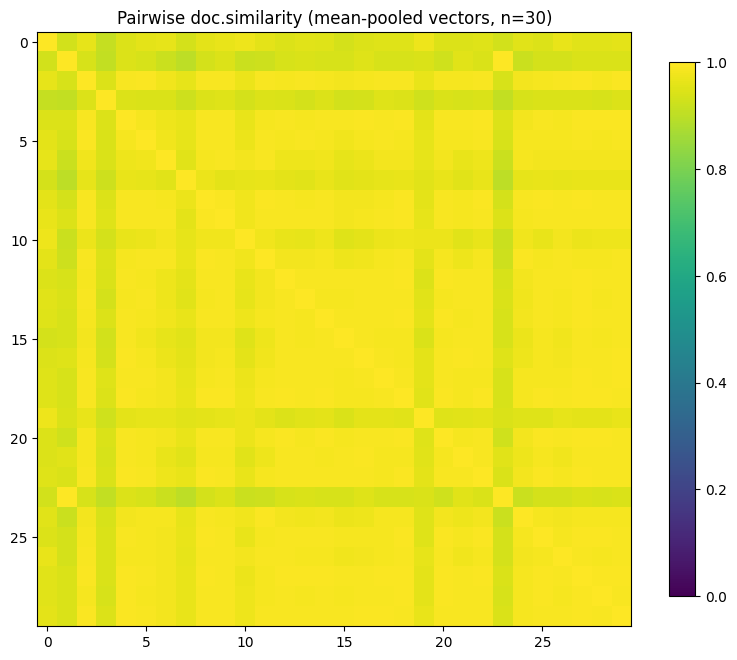

In [34]:
sim_matrix = eda_utils_spacy.doc_similarity_matrix(
    docs, doc_index, sample_n=30, random_state=0
)
print('shape:', sim_matrix.shape)
print('diag mean:', np.diag(sim_matrix).mean())

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix.values, cmap='viridis', vmin=0, vmax=1)
ax.set_title('Pairwise doc.similarity (mean-pooled vectors, n=30)')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(ARTIFACTS / 'similarity' / 'doc_similarity_sample.png', dpi=120)
plt.show()

## AI Notes

What spaCy gave us on this corpus:
* **NER** -- stock model picks up `ORG` (Waymo, Cruise, Zoox) and `GPE` (Phoenix, Arizona, San Francisco) cleanly. The `org_vs_master_entity_crosstab` is the natural sanity check; mismatches usually trace to redaction sentinels that snuck past `preprocess_narratives` or to multi-reporter narratives.
* **Noun chunks** -- catches multi-word AV phrases (`pickup truck`, `parking lot`, `left turn`) more cleanly than raw bigrams. A natural successor to the n-gram baseline in `03_eda_basic_topics_2026.ipynb`.
* **Rule-based matching** -- cheap, interpretable, and joinable. The maneuver flags slot directly into a per-reporter `groupby` without retraining anything.
* **Similarity** -- the mean-pooled vector limitation shows up immediately: documents that share rare named entities cluster, but documents that share semantic structure (a turn, a rear-end, a yield) don't. Contextual embeddings belong in the BERTopic / sentence-transformer track.

Follow-ups to consider (see plan `Deferred to Follow-Up Work`):
* Custom NER for AV-specific entity types (MANEUVER, CONTACT_AREA) -- needs labeled data.
* Dependency parsing for subject-verb-object fault patterns.
* Re-tokenizing the LDA / NMF pipelines on spaCy lemmas.